In [8]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [9]:
#Finding Anomaly using a simple machine learning algorithm

data = pd.read_csv('final_data.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])
target_sensor = data.loc[data['name']=='Innenstadt', 'SID'].iloc[0]
sensor_data = data[data['SID']==target_sensor].sort_values('timestamp').reset_index(drop=True)


features = ['visitors','hour_sin','hour_cos','weekday_sin','weekday_cos']
scaler = StandardScaler()
X = sensor_data[features]
X['visitors'] = scaler.fit_transform(X[['visitors']])   

iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X)        
sensor_data['iso_anomaly'] = (iso_pred == -1).astype(int)

print("Isolation Forest flagged:", sensor_data['iso_anomaly'].sum(), "/", len(sensor_data))


Isolation Forest flagged: 17 / 335


NameError: name 'anomalies' is not defined

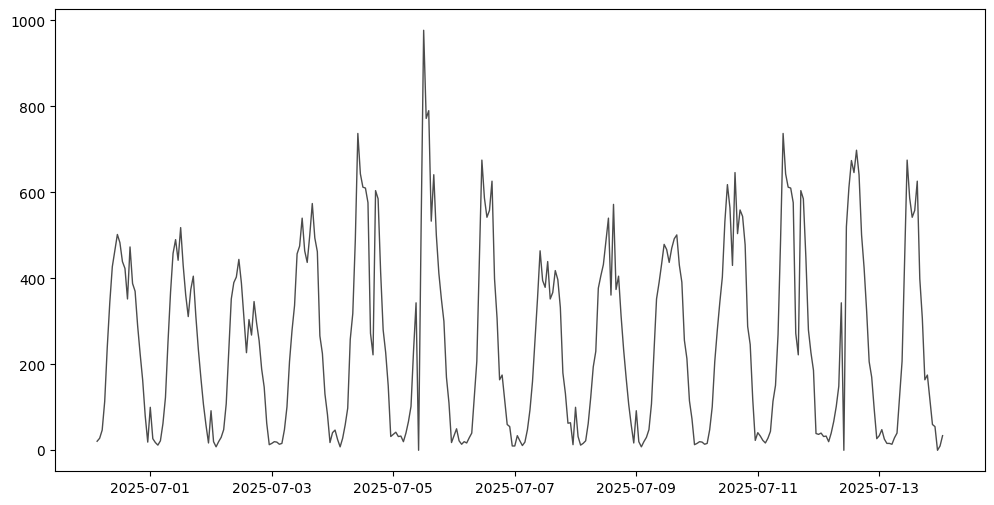

In [10]:
# Plot anomalies detected by Isolation Forest
plt.figure(figsize=(12, 6))
plt.plot(sensor_data['timestamp'], sensor_data['visitors'], label='Visitor Count', alpha=0.7,color = 'black', linewidth= 1)
plt.scatter(
    anomalies['timestamp'], 
    anomalies['visitors'], 
    color='red',
    marker= 'o',
    label= f"Anomaly- {len(anomalies)}"
)
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Timestamp')
plt.ylabel('Visitors')
plt.legend()
plt.tight_layout()
plt.savefig('isolation_forest.png')
plt.show()

In [5]:
#Save to compare with model
anomalies.to_csv('isolation_forest.csv',index=False)

NameError: name 'anomalies' is not defined